In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math


# 🔹 Entropy
def entropy_test(series):
    keys = [int(x * 256) for x in series]
    count = Counter(keys)
    total = len(keys)
    entropy = -sum((c/total) * math.log2(c/total) for c in count.values())
    return entropy


# 🔹 Autocorrelation (lag 1)
def autocorrelation_value(series):
    z = np.array(series)
    z_mean = np.mean(z)
    num = np.sum((z[:-1] - z_mean) * (z[1:] - z_mean))
    den = np.sum((z - z_mean) ** 2)
    return num / den


# 🔹 Correlation coefficient
def correlation_coeff(series):
    x = np.array(series[:-1])
    y = np.array(series[1:])
    return np.corrcoef(x, y)[0, 1]


# 🔹 MASTER TEST FUNCTION
def test_randomness(series):
    print("========== RANDOMNESS TEST REPORT ==========\n")

    arr = np.array(series)

    # 🔸 Mean
    mean = np.mean(arr)
    print("Mean:")
    print(f"  Value: {mean:.5f}")
    print("  Ideal: 0.5")
    print("  Accepted: 0.48 – 0.52")
    if 0.48 <= mean <= 0.52:
        print("  Result: PASS\n")
    else:
        print("  Result: FAIL\n")

    # 🔸 Variance
    variance = np.var(arr)
    print("Variance:")
    print(f"  Value: {variance:.5f}")
    print("  Ideal: 0.0833")
    print("  Accepted: 0.07 – 0.09")
    if 0.07 <= variance <= 0.09:
        print("  Result: PASS\n")
    else:
        print("  Result: FAIL\n")

    # 🔸 Entropy
    entropy = entropy_test(series)
    print("Entropy:")
    print(f"  Value: {entropy:.5f}")
    print("  Ideal: 8")
    print("  Accepted: ≥ 7.5 (≥7.9 excellent)")
    if entropy >= 7.9:
        print("  Result: EXCELLENT\n")
    elif entropy >= 7.5:
        print("  Result: PASS (GOOD)\n")
    else:
        print("  Result: FAIL\n")

    # 🔸 Autocorrelation
    auto = autocorrelation_value(series)
    print("Autocorrelation (lag 1):")
    print(f"  Value: {auto:.5f}")
    print("  Ideal: 0")
    print("  Accepted: |value| < 0.05")
    if abs(auto) < 0.05:
        print("  Result: PASS\n")
    else:
        print("  Result: FAIL\n")

    # 🔸 Correlation
    corr = correlation_coeff(series)
    print("Correlation (x_n vs x_n+1):")
    print(f"  Value: {corr:.5f}")
    print("  Ideal: 0")
    print("  Accepted: -0.05 to 0.05")
    if -0.05 <= corr <= 0.05:
        print("  Result: PASS\n")
    else:
        print("  Result: FAIL\n")

    # 🔸 Histogram
    print("Histogram:")
    print("  Ideal: Uniform (flat distribution)")
    print("  Check visually in the plot")

    plt.figure()
    plt.hist(series, bins=50)
    plt.title("Histogram")
    plt.show()

    # 🔸 Correlation Plot
    plt.figure()
    plt.scatter(series[:-1], series[1:], s=1)
    plt.title("Correlation Plot")
    plt.show()

    print("\n========== TESTING COMPLETE ==========")

In [10]:
def henon_map(a, b, x0, y0, n):
    x = x0
    y = y0
    
    x_vals = []
    y_vals = []
    
    for i in range(n):
        x_next = 1 - a * x * x + y
        y_next = b * x
        
        x_vals.append(x_next)
        y_vals.append(y_next)
        
        x, y = x_next, y_next
    
    return x_vals, y_vals


# Parameters
a = 1.4
b = 0.3
x0 = 0.1   # initial value
y0 = 0.1
iterations = 1000

# Generate series
x_series, y_series = henon_map(a, b, x0, y0, iterations)

# Print first 10 values
for i in range(10):
    print(f"{i}: x = {x_series[i]}, y = {y_series[i]}")

0: x = 1.086, y = 0.03
1: x = -0.6211544, y = 0.32580000000000003
2: x = 0.785634095904896, y = -0.18634631999999998
3: x = -0.050455625707624546, y = 0.23569022877146878
4: x = 1.2321261505397016, y = -0.015136687712287364
5: x = -1.1405254788935844, y = 0.3696378451619105
6: x = -0.4514798700457054, y = -0.3421576436680753
7: x = 0.3724746540528429, y = -0.13544396101371162
8: x = 0.6703237239097894, y = 0.11174239621585287
9: x = 0.4826749434450502, y = 0.20109711717293682


In [11]:
normalized = [(x % 1) for x in x_series]

In [12]:
normalized

[0.08600000000000008,
 0.3788456,
 0.785634095904896,
 0.9495443742923755,
 0.23212615053970165,
 0.8594745211064156,
 0.5485201299542946,
 0.3724746540528429,
 0.6703237239097894,
 0.4826749434450502,
 0.8749319757313814,
 0.0730941360134092,
 0.25499973891204886,
 0.8168941582669877,
 0.41686471583372353,
 0.16900278398453877,
 0.7850726973577826,
 0.18782603900408723,
 0.18613173990818388,
 0.08667590551656446,
 0.18801425978287278,
 0.6765136650205872,
 0.41566524339143973,
 0.9610654671170454,
 0.8315940080985653,
 0.24861483078348523,
 0.7668236085161095,
 0.24557083171652438,
 0.8332183646151775,
 0.7347286900526672,
 0.19420876220344174,
 0.1676147463725699,
 0.14960875433567977,
 0.33785304492825097,
 0.585080074346497,
 0.6221097427222518,
 0.6336952775180242,
 0.6244353361685715,
 0.6442212985770676,
 0.606301086694119,
 0.6786249787560629,
 0.5371457194999023,
 0.799651760058924,
 0.26592360353850164,
 0.1408940199312141,
 0.25748225046082285,
 0.5704025542463504,
 0.321741

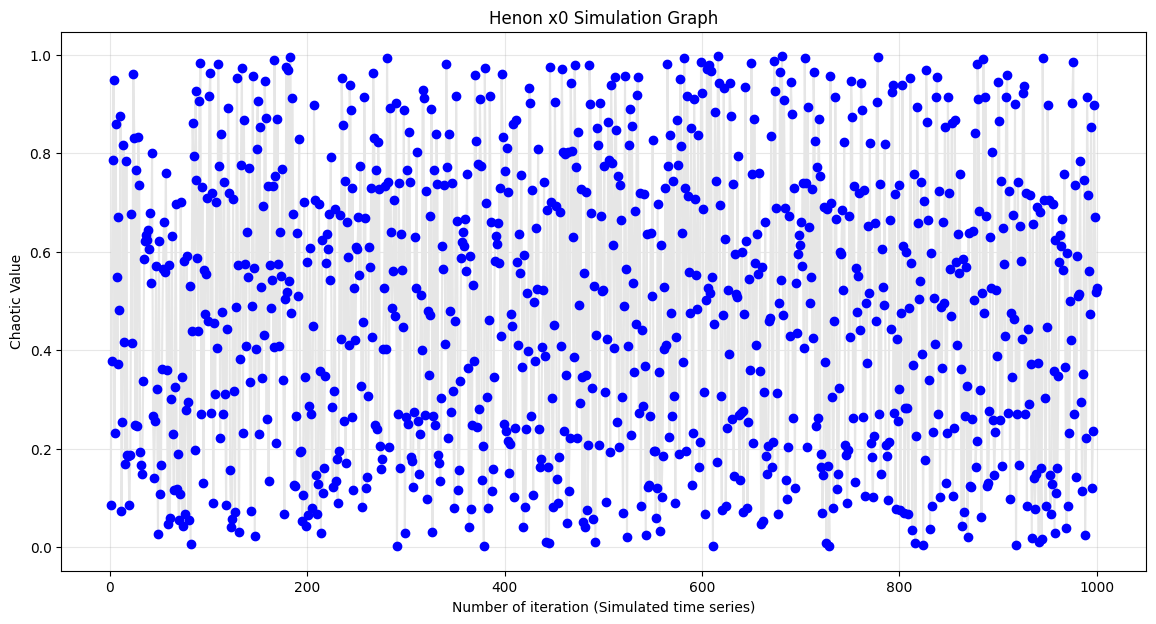

In [13]:
iterations=[]
for i in range(1,1001):#100 iterations
    iterations.append(i)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    iterations, 
    normalized,
    color='#e6e6e6',        # slightly visible off-white line
    linewidth=1.5,          # helps visibility
    marker='o',
    markerfacecolor='blue',
    markeredgecolor='blue'
)

plt.xlabel("Number of iteration (Simulated time series)")
plt.ylabel("Chaotic Value")
plt.title("Henon x0 Simulation Graph")

plt.grid(True, alpha=0.3)  # softer grid so it doesn’t overpower
plt.show()

In [17]:
def chaotic_function(x_n,r=3.9):
    ''' The function is a simulation of chatoic behaviour 
        based on equation  x_n+1 = r * x_n * (1 - x_n)
        where each new_value(x_n+1) is based on old_value(x_n) with a seed vaue r 
    '''
    '''Arguments 
        x_n (previous value and seed value)
        r=custom chatoic constant
    '''
    return r*x_n*(1-x_n)

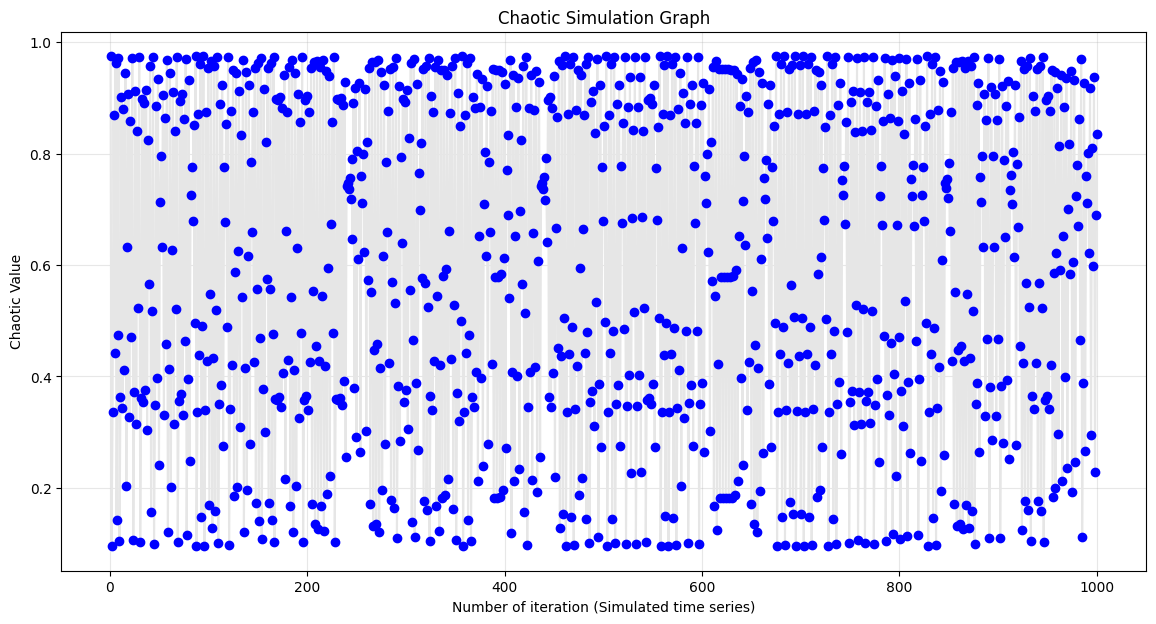

In [18]:
my_values=[] ; iterations=[]
r=3.9
x_n =0.5
for i in range(1,1001):#100 iterations
    x_n_1 = chaotic_function(x_n,r)
    my_values.append(x_n_1)
    x_n=x_n_1
    iterations.append(i)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    iterations, 
    my_values,
    color='#e6e6e6',        # slightly visible off-white line
    linewidth=1.5,          # helps visibility
    marker='o',
    markerfacecolor='blue',
    markeredgecolor='blue'
)

plt.xlabel("Number of iteration (Simulated time series)")
plt.ylabel("Chaotic Value")
plt.title("Chaotic Simulation Graph")

plt.grid(True, alpha=0.3)  # softer grid so it doesn’t overpower
plt.show()

Combine Logistic with hennon

0.06099999999999994
0.47390810000000005
0.12113401817052116
0.8190092995513758
0.6747592596528107
0.8216397764433045
0.6904929093159085
0.8475590402524572
0.6429026514466942
0.5866846567125185
0.23837957770398188
0.9753725621259792
0.5988708036611836
0.696826805018969
0.8289043331686567
0.11382837120205735
0.9883804654884829
0.8195235452429006
0.09348923062504699
0.41450941706832184
0.04741319077893724
0.14776005777624324
0.38744084066614803
0.06803383179980527
0.2041459292940031
0.16026708089868702
0.08093906591896549
0.08581388532798129
0.35673355604486745
0.7075721295635649
0.2972431808783075
0.528046222621043
0.04863920032917557
0.6918743872921551
0.4769719772540748
0.9981506148206148
0.5487684024965
0.9275211097589215
0.4679979695832752
0.17245888921145713
0.6365552449037628
0.6943152177488994
0.316274023628631
0.2398460349183964
0.23994438316759298
0.605515866699392
0.4553368052515969
0.718861899062998
0.959916904945561
0.8635690106174334
0.8221484455044626
0.9640143513851226
0.9

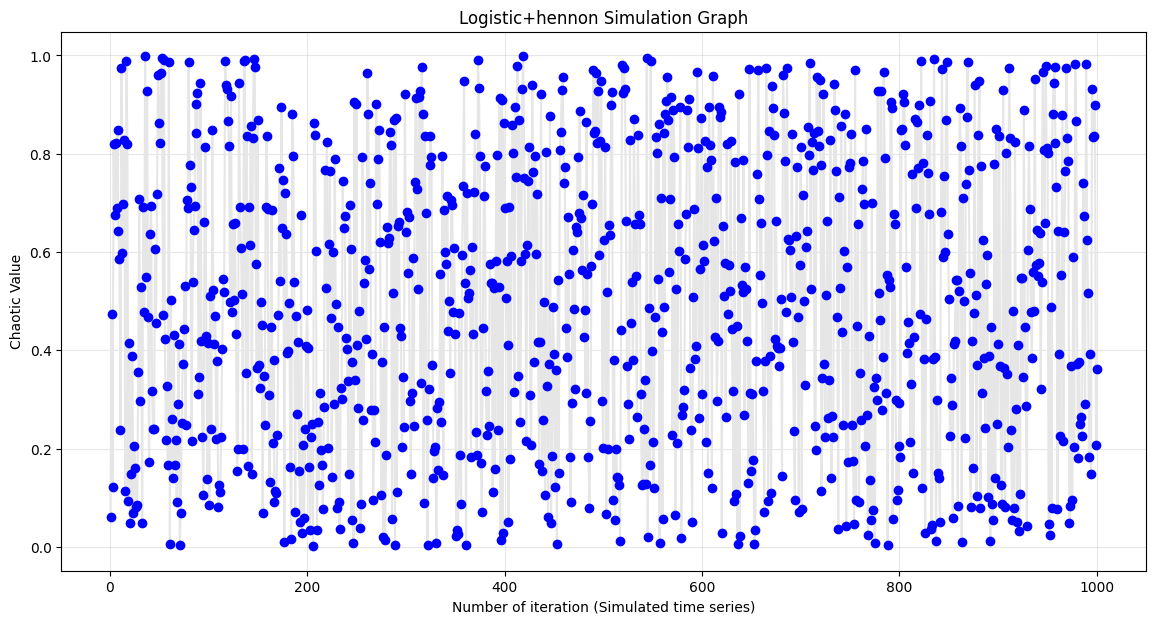

In [20]:
z_value1=[]
for i in range (len(my_values)):
    z_value1.append((my_values[i] + normalized[i]) % 1)


for value in z_value1:
    print(value)

# import matplotlib.pyplot as plt
# plt.figure(figsize=(14,7))
# plt.plot(iterations, z_value1 ,marker="o")
# plt.xlabel("Number of iteration (Simulated time series)")
# plt.ylabel("Chaotic Value")
# plt.title("Logistic + Henon x0 Simulation Graph")
# plt.grid(True)
# plt.show()


import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    iterations, 
    z_value1,
    color='#e6e6e6',        # slightly visible off-white line
    linewidth=1.5,          # helps visibility
    marker='o',
    markerfacecolor='blue',
    markeredgecolor='blue'
)

plt.xlabel("Number of iteration (Simulated time series)")
plt.ylabel("Chaotic Value")
plt.title("Logistic+hennon Simulation Graph")

plt.grid(True, alpha=0.3)  # softer grid so it doesn’t overpower
plt.show()

========== RANDOMNESS TEST REPORT ==========

Mean:
  Value: 0.59227
  Ideal: 0.5
  Accepted: 0.48 – 0.52
  Result: FAIL

Variance:
  Value: 0.08952
  Ideal: 0.0833
  Accepted: 0.07 – 0.09
  Result: PASS

Entropy:
  Value: 7.30397
  Ideal: 8
  Accepted: ≥ 7.5 (≥7.9 excellent)
  Result: FAIL

Autocorrelation (lag 1):
  Value: -0.50097
  Ideal: 0
  Accepted: |value| < 0.05
  Result: FAIL

Correlation (x_n vs x_n+1):
  Value: -0.50171
  Ideal: 0
  Accepted: -0.05 to 0.05
  Result: FAIL

Histogram:
  Ideal: Uniform (flat distribution)
  Check visually in the plot


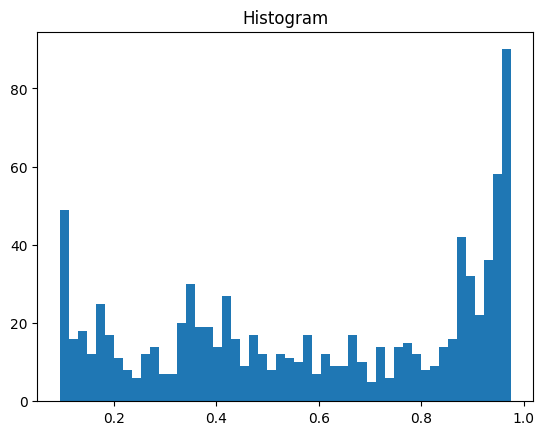

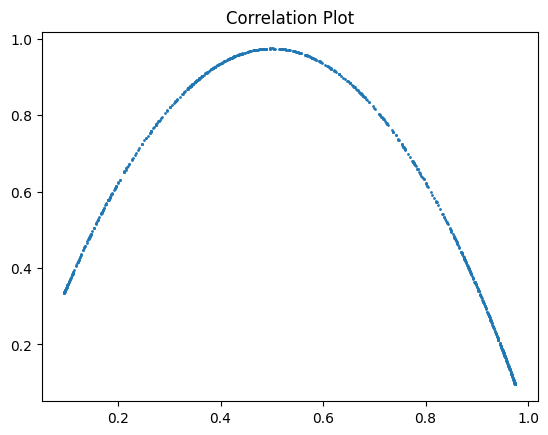


========== TESTING COMPLETE ==========


In [21]:
test_randomness(my_values[100:])

========== RANDOMNESS TEST REPORT ==========

Mean:
  Value: 0.49329
  Ideal: 0.5
  Accepted: 0.48 – 0.52
  Result: PASS

Variance:
  Value: 0.08230
  Ideal: 0.0833
  Accepted: 0.07 – 0.09
  Result: PASS

Entropy:
  Value: 7.72935
  Ideal: 8
  Accepted: ≥ 7.5 (≥7.9 excellent)
  Result: PASS (GOOD)

Autocorrelation (lag 1):
  Value: 0.04067
  Ideal: 0
  Accepted: |value| < 0.05
  Result: PASS

Correlation (x_n vs x_n+1):
  Value: 0.04072
  Ideal: 0
  Accepted: -0.05 to 0.05
  Result: PASS

Histogram:
  Ideal: Uniform (flat distribution)
  Check visually in the plot


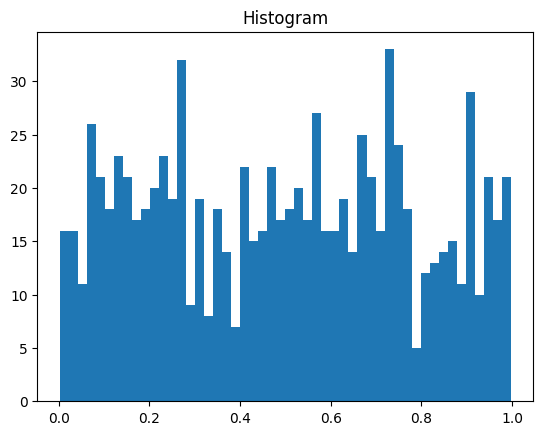

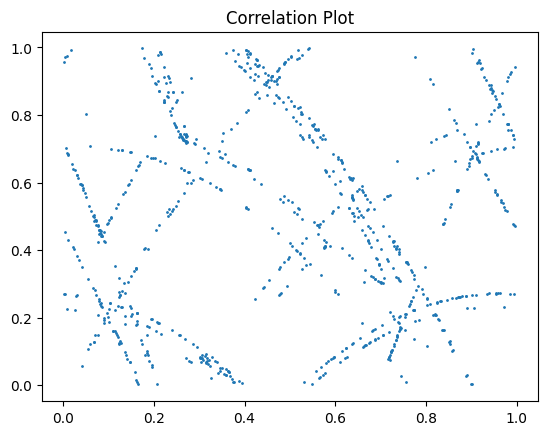


========== TESTING COMPLETE ==========


In [22]:
test_randomness(normalized[100:])

========== RANDOMNESS TEST REPORT ==========

Mean:
  Value: 0.49891
  Ideal: 0.5
  Accepted: 0.48 – 0.52
  Result: PASS

Variance:
  Value: 0.08636
  Ideal: 0.0833
  Accepted: 0.07 – 0.09
  Result: PASS

Entropy:
  Value: 7.80956
  Ideal: 8
  Accepted: ≥ 7.5 (≥7.9 excellent)
  Result: PASS (GOOD)

Autocorrelation (lag 1):
  Value: 0.17403
  Ideal: 0
  Accepted: |value| < 0.05
  Result: FAIL

Correlation (x_n vs x_n+1):
  Value: 0.17424
  Ideal: 0
  Accepted: -0.05 to 0.05
  Result: FAIL

Histogram:
  Ideal: Uniform (flat distribution)
  Check visually in the plot


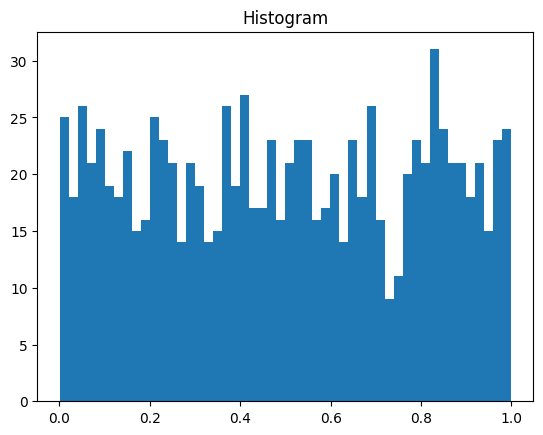

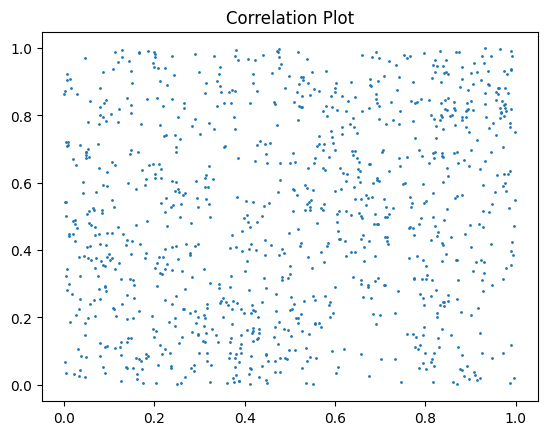


========== TESTING COMPLETE ==========


In [23]:
test_randomness(z_value1)